In [1]:
%pip install timm

  Using cached huggingface_hub-1.17.0-py3-none-any.whl.metadata (14 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import timm
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

d:\Conda\envs\EDU\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)
DATA_DIR = "COVID_19_dataset"

cuda


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [4]:
model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=True,
    num_classes=3
)

model = model.to(device)

print(
    f"Parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Parameters: 21,666,819


In [5]:
train_dataset = datasets.ImageFolder(
    f"{DATA_DIR}/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    f"{DATA_DIR}/val",
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    f"{DATA_DIR}/test",
    transform=test_transform
)

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [9]:
print(train_dataset.classes)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

['COVID', 'Normal', 'Viral Pneumonia']
Train: 3000
Val: 600
Test: 435


In [10]:
import timm

model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=True,
    num_classes=3
).to(device)

print(
    f"Parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Parameters: 21,666,819


In [ ]:
import torch
from tqdm import tqdm

num_epochs = 30

best_val_acc = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(num_epochs):

   

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}"
    )

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*correct/total:.2f}%"
        )

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = (
        100 * correct /
        total
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)

   
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            preds = outputs.argmax(1)

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    val_loss /= len(val_loader)

    val_acc = (
        100 * correct /
        total
    )

    val_losses.append(val_loss)
    val_accs.append(val_acc)


    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_deit_small.pth"
        )

        print(
            f"\nSaved Best Model "
            f"(Val Acc = {val_acc:.2f}%)"
        )

    scheduler.step()

    

    print(
        f"\nEpoch {epoch+1}/{num_epochs}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Acc : {train_acc:.2f}%"
    )

    print(
        f"Val Loss  : {val_loss:.4f}"
    )

    print(
        f"Val Acc   : {val_acc:.2f}%"
    )

print(
    f"\nBest Validation Accuracy: "
    f"{best_val_acc:.2f}%"
)

Epoch 1/30: 100%|██████████| 94/94 [00:35<00:00,  2.64it/s, acc=95.97%, loss=0.2578]



Saved Best Model (Val Acc = 95.33%)

Epoch 1/30
Train Loss: 0.1035
Train Acc : 95.97%
Val Loss  : 0.1072
Val Acc   : 95.33%


Epoch 2/30: 100%|██████████| 94/94 [00:35<00:00,  2.64it/s, acc=97.37%, loss=0.1118]



Epoch 2/30
Train Loss: 0.0759
Train Acc : 97.37%
Val Loss  : 0.1292
Val Acc   : 95.00%


Epoch 3/30: 100%|██████████| 94/94 [00:34<00:00,  2.74it/s, acc=97.97%, loss=0.0769]


...


Epoch 28/30
Train Loss: 0.0009
Train Acc : 100.00%
Val Loss  : 0.0795
Val Acc   : 98.33%


Epoch 29/30: 100%|██████████| 94/94 [00:34<00:00,  2.75it/s, acc=100.00%, loss=0.0001]



Epoch 29/30
Train Loss: 0.0011
Train Acc : 100.00%
Val Loss  : 0.0795
Val Acc   : 98.33%


Epoch 30/30: 100%|██████████| 94/94 [00:34<00:00,  2.75it/s, acc=99.97%, loss=0.0012] 



Epoch 30/30
Train Loss: 0.0016
Train Acc : 99.97%
Val Loss  : 0.0825
Val Acc   : 98.50%

Best Validation Accuracy: 98.50%


In [8]:
model.load_state_dict(
    torch.load(
        "best_deit_small.pth"
    )
)

model.eval()

C:\Users\sidha\AppData\Local\Temp\ipykernel_13760\1416218497.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [12]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

print(
    f"Test Accuracy: "
    f"{100*correct/total:.2f}%"
)

Test Accuracy: 98.85%


In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [14]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[143   1   1]
 [  1 144   0]
 [  1   1 143]]


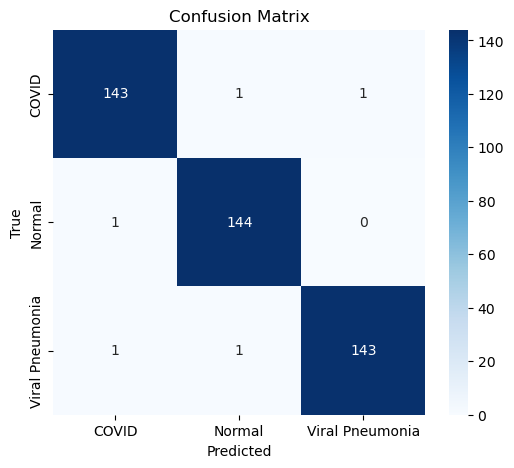

In [19]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

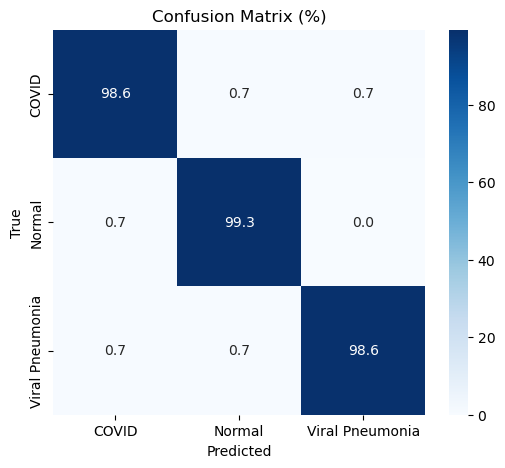

In [20]:
cm_percent = (
    cm.astype(float)
    / cm.sum(axis=1, keepdims=True)
) * 100

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (%)")

plt.show()

In [15]:
print(model.blocks[0].attn)

Attention(
  (qkv): Linear(in_features=384, out_features=1152, bias=True)
  (q_norm): Identity()
  (k_norm): Identity()
  (attn_drop): Dropout(p=0.0, inplace=False)
  (norm): Identity()
  (proj): Linear(in_features=384, out_features=384, bias=True)
  (proj_drop): Dropout(p=0.0, inplace=False)
)


In [16]:
for name, module in model.blocks[0].attn.named_modules():
    print(name)


qkv
q_norm
k_norm
attn_drop
norm
proj
proj_drop


In [17]:
print(model.blocks[0])

Block(
  (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (attn): Attention(
    (qkv): Linear(in_features=384, out_features=1152, bias=True)
    (q_norm): Identity()
    (k_norm): Identity()
    (attn_drop): Dropout(p=0.0, inplace=False)
    (norm): Identity()
    (proj): Linear(in_features=384, out_features=384, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (ls1): Identity()
  (drop_path1): Identity()
  (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (mlp): Mlp(
    (fc1): Linear(in_features=384, out_features=1536, bias=True)
    (act): GELU(approximate='none')
    (drop1): Dropout(p=0.0, inplace=False)
    (norm): Identity()
    (fc2): Linear(in_features=1536, out_features=384, bias=True)
    (drop2): Dropout(p=0.0, inplace=False)
  )
  (ls2): Identity()
  (drop_path2): Identity()
)


In [21]:
for block in model.blocks:
    block.attn.fused_attn = False

In [22]:
attentions = []

def hook_fn(module, input, output):
    attentions.append(output)

hooks = []

for block in model.blocks:
    hooks.append(
        block.attn.attn_drop.register_forward_hook(
            hook_fn
        )
    )

In [23]:
img, label = test_dataset[433]

input_tensor = (
    img.unsqueeze(0)
       .to(device)
)

In [24]:
attentions.clear()

with torch.no_grad():
    _ = model(input_tensor)

print(len(attentions))
print(attentions[0].shape)

24
torch.Size([1, 6, 197, 197])


In [25]:
result = torch.eye(
    attentions[0].size(-1)
).to(device)

for attn in attentions:

    # Average heads
    attn_heads_fused = attn.mean(dim=1)

    # Add residual connection
    attn_heads_fused = (
        attn_heads_fused
        + torch.eye(
            attn_heads_fused.size(-1)
        ).to(device)
    )

    # Normalize
    attn_heads_fused = (
        attn_heads_fused
        / attn_heads_fused.sum(
            dim=-1,
            keepdim=True
        )
    )

    # Rollout
    result = torch.matmul(
        attn_heads_fused,
        result
    )

In [26]:
mask = result[
    0,
    0,
    1:
].reshape(14,14)

In [27]:
mask = mask.cpu().numpy()

mask = (
    mask - mask.min()
) / (
    mask.max() - mask.min()
)

In [28]:
import cv2

mask = cv2.resize(
    mask,
    (224,224)
)

In [29]:
mean = np.array(
    [0.485,0.456,0.406]
)

std = np.array(
    [0.229,0.224,0.225]
)

rgb_img = (
    img.permute(1,2,0)
       .cpu()
       .numpy()
)

rgb_img = rgb_img * std + mean

rgb_img = np.clip(
    rgb_img,
    0,
    1
)

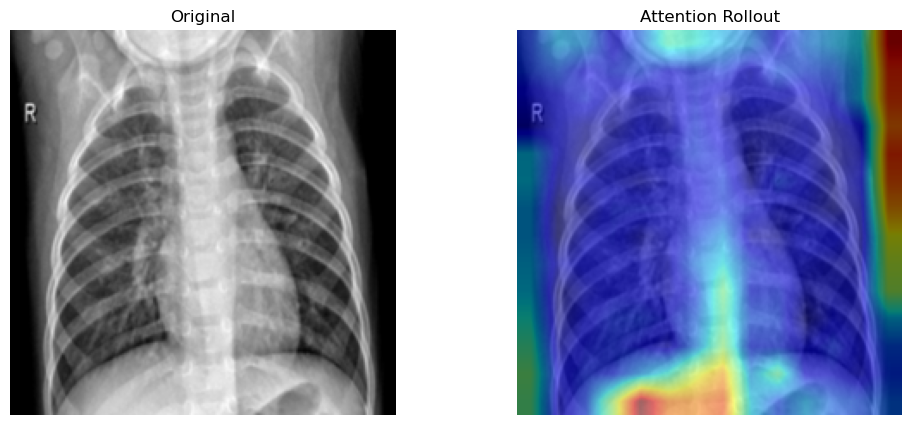

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.imshow(rgb_img)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(rgb_img)

plt.imshow(
    mask,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "Attention Rollout"
)

plt.axis("off")

plt.show()

In [10]:
import numpy as np

def compute_entropy(cam):

    cam = cam.astype(np.float64)

    cam = cam - cam.min()

    if cam.max() > 0:
        cam = cam / cam.max()

    prob = cam.flatten()

    prob = prob / (prob.sum() + 1e-12)

    entropy = -np.sum(
        prob * np.log2(prob + 1e-12)
    )

    return entropy

In [ ]:
import numpy as np
from tqdm import tqdm
import torch
import cv2

entropies = []

for idx in tqdm(range(len(test_dataset))):

    img, label = test_dataset[idx]

    input_tensor = (
        img.unsqueeze(0)
           .to(device)
    )

    attentions.clear()

    with torch.no_grad():
        _ = model(input_tensor)

   

    result = torch.eye(
        attentions[0].size(-1)
    ).to(device)

    for attn in attentions:

        attn_heads_fused = attn.mean(dim=1)

        attn_heads_fused = (
            attn_heads_fused
            + torch.eye(
                attn_heads_fused.size(-1)
            ).to(device)
        )

        attn_heads_fused = (
            attn_heads_fused
            / attn_heads_fused.sum(
                dim=-1,
                keepdim=True
            )
        )

        result = torch.matmul(
            attn_heads_fused,
            result
        )

    

    mask = result[
        0,
        0,
        1:
    ].reshape(14,14)

    mask = mask.cpu().numpy()

    mask = (
        mask - mask.min()
    ) / (
        mask.max() - mask.min() + 1e-8
    )

    mask = cv2.resize(
        mask,
        (224,224)
    )

    entropies.append(
        compute_entropy(mask)
    )

print(
    f"Mean Entropy: "
    f"{np.mean(entropies):.4f}"
)

print(
    f"Std Entropy: "
    f"{np.std(entropies):.4f}"
)

100%|██████████| 435/435 [00:08<00:00, 49.08it/s]

Mean Entropy: 15.3120
Std Entropy: 0.0809


In [60]:
class_entropies = {
    0: [],
    1: [],
    2: []
}

for idx in tqdm(range(len(test_dataset))):

    img, label = test_dataset[idx]

    # generate rollout mask
    # ...

    class_entropies[label].append(
        compute_entropy(mask)
    )

for cls in range(3):

    print(
        f"{train_dataset.classes[cls]}: "
        f"{np.mean(class_entropies[cls]):.4f}"
        f" ± "
        f"{np.std(class_entropies[cls]):.4f}"
    )

100%|██████████| 435/435 [00:01<00:00, 324.63it/s]

COVID: 15.3083 ± 0.0000
Normal: 15.3083 ± 0.0000
Viral Pneumonia: 15.3083 ± 0.0000


In [32]:
def get_rollout_map(model, input_tensor):

    attentions.clear()

    with torch.no_grad():
        _ = model(input_tensor)

    result = torch.eye(
        attentions[0].size(-1)
    ).to(device)

    for attn in attentions:

        attn_heads_fused = attn.mean(dim=1)

        attn_heads_fused = (
            attn_heads_fused
            + torch.eye(
                attn_heads_fused.size(-1)
            ).to(device)
        )

        attn_heads_fused = (
            attn_heads_fused
            / attn_heads_fused.sum(
                dim=-1,
                keepdim=True
            )
        )

        result = torch.matmul(
            attn_heads_fused,
            result
        )

    mask = result[
        0,
        0,
        1:
    ].reshape(14,14)

    mask = mask.cpu().numpy()

    mask = (
        mask - mask.min()
    ) / (
        mask.max() - mask.min()
        + 1e-8
    )

    mask = cv2.resize(
        mask,
        (224,224)
    )

    return mask

In [34]:
img, label = test_dataset[0]

input_tensor = (
    img.unsqueeze(0)
       .to(device)
)

rollout_map = get_rollout_map(
    model,
    input_tensor
)

print(rollout_map.shape)
print(
    rollout_map.min(),
    rollout_map.max()
)

(224, 224)
0.00060521386 0.99999946


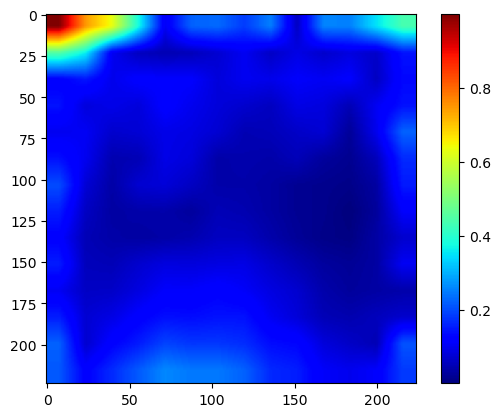

In [35]:
plt.imshow(
    rollout_map,
    cmap="jet"
)
plt.colorbar()
plt.show()

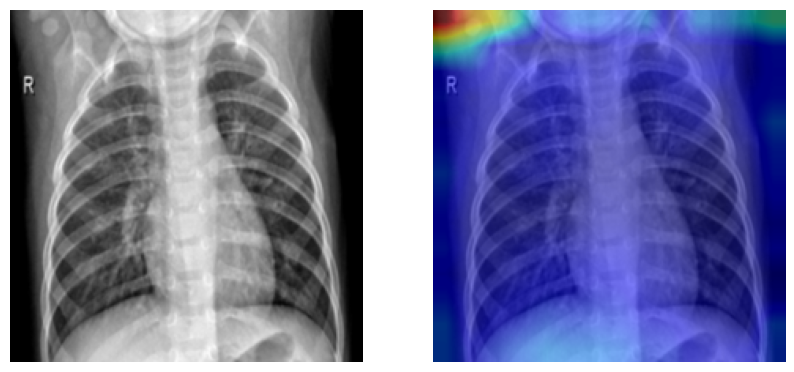

In [37]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb_img)
plt.imshow(
    rollout_map,
    cmap="jet",
    alpha=0.5
)
plt.axis("off")

plt.show()

100%|██████████| 400/400 [01:47<00:00,  3.73it/s]

Rollout DAUC = 0.6489



C:\Users\sidha\AppData\Local\Temp\ipykernel_23312\1607951449.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  dauc = np.trapz(


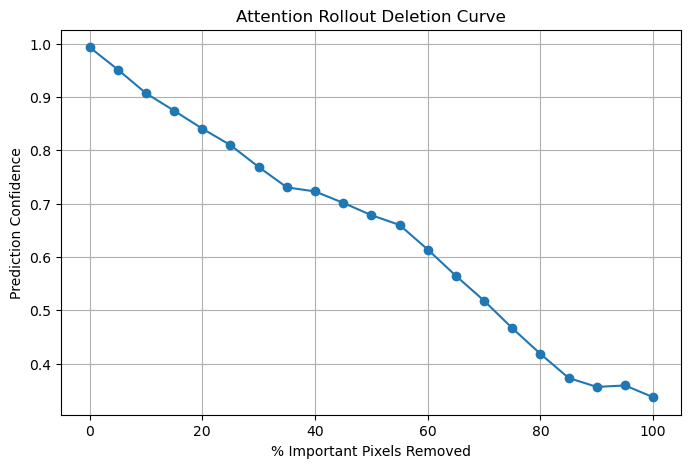

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

steps = 20
N = 400

sample_indices = random.sample(
    range(len(test_dataset)),
    N
)

mean_curve = np.zeros(
    steps + 1
)

for idx in tqdm(sample_indices):

    img, label = test_dataset[idx]

    input_tensor = (
        img.unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        output = model(
            input_tensor
        )

        pred_class = (
            output.argmax(1)
            .item()
        )

    

    rollout_map = get_rollout_map(
        model,
        input_tensor
    )

    rollout_map = (
        rollout_map
        - rollout_map.min()
    ) / (
        rollout_map.max()
        - rollout_map.min()
        + 1e-8
    )

    flat_map = rollout_map.flatten()

    sorted_idx = np.argsort(
        flat_map
    )[::-1]

    confidences = []

    for step in range(
        steps + 1
    ):

        frac = (
            step / steps
        )

        modified_img = (
            img.clone()
        )

        n_remove = int(
            frac *
            len(sorted_idx)
        )

        remove_idx = (
            sorted_idx[
                :n_remove
            ]
        )

        mask = np.ones(
            flat_map.shape,
            dtype=np.float32
        )

        mask[
            remove_idx
        ] = 0

        mask = mask.reshape(
            rollout_map.shape
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        modified_img *= mask

        with torch.no_grad():

            prob = torch.softmax(
                model(
                    modified_img
                    .unsqueeze(0)
                    .to(device)
                ),
                dim=1
            )[0, pred_class]

        confidences.append(
            prob.item()
        )

    mean_curve += np.array(
        confidences
    )

mean_curve /= N

x = np.linspace(
    0,
    1,
    steps + 1
)

dauc = np.trapz(
    mean_curve,
    x
)

print(
    f"Rollout DAUC = {dauc:.4f}"
)

plt.figure(
    figsize=(8,5)
)

plt.plot(
    x * 100,
    mean_curve,
    marker='o'
)

plt.xlabel(
    "% Important Pixels Removed"
)

plt.ylabel(
    "Prediction Confidence"
)

plt.title(
    "Attention Rollout Deletion Curve"
)

plt.grid(True)

plt.show()

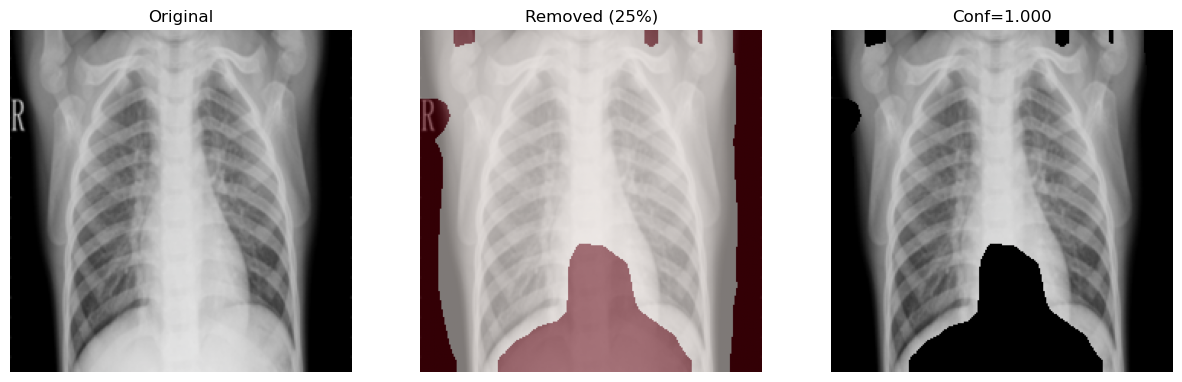

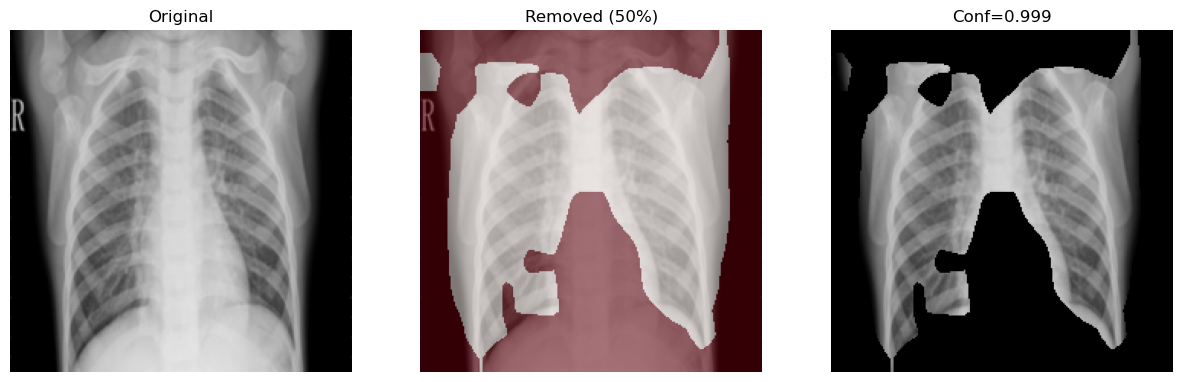

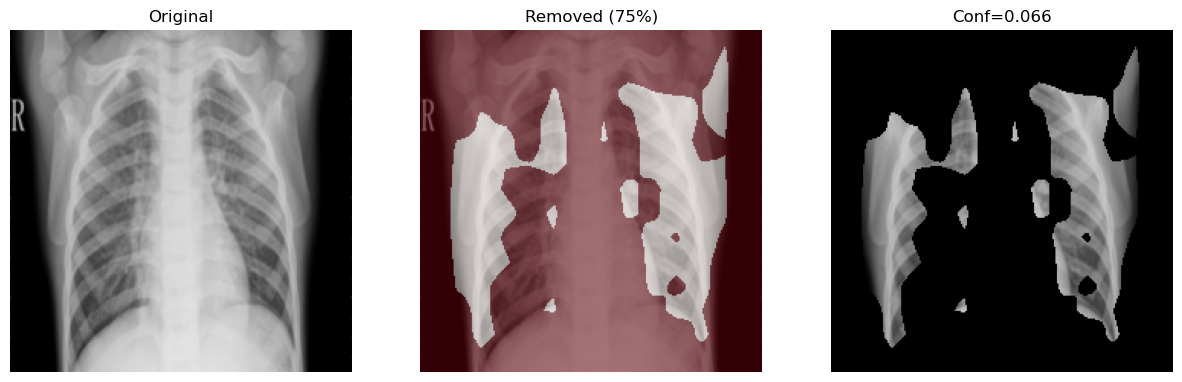

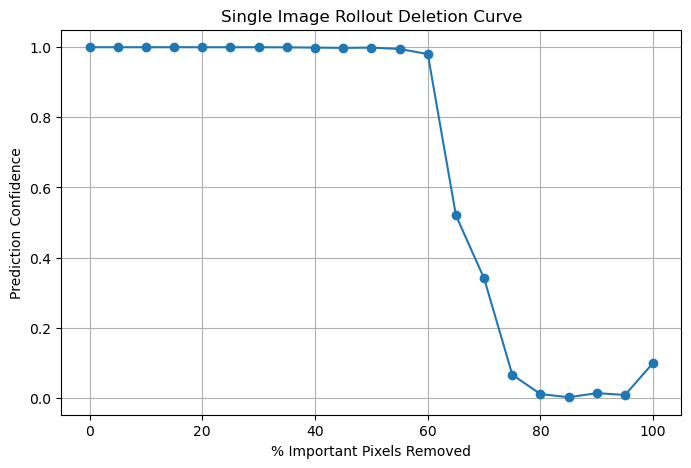

In [ ]:
idx = 400

img, label = test_dataset[idx]

input_tensor = img.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    pred_class = output.argmax(1).item()

rollout_map = get_rollout_map(
    model,
    input_tensor
)

rollout_map = (
    rollout_map - rollout_map.min()
) / (
    rollout_map.max()
    - rollout_map.min()
    + 1e-8
)

flat_map = rollout_map.flatten()

sorted_idx = np.argsort(
    flat_map
)[::-1]

rgb_img = (
    img.permute(1,2,0)
       .cpu()
       .numpy()
)

rgb_img = rgb_img * std + mean
rgb_img = np.clip(rgb_img,0,1)

steps = 20

confidences = []

for step in range(steps + 1):

    frac = step / steps

    modified_img = img.clone()

    n_remove = int(
        frac * len(sorted_idx)
    )

    remove_idx = (
        sorted_idx[:n_remove]
    )

    mask = np.ones(
        flat_map.shape,
        dtype=np.float32
    )

    mask[remove_idx] = 0

    mask = mask.reshape(
        rollout_map.shape
    )

    mask_tensor = torch.tensor(
        mask,
        dtype=torch.float32
    )

    modified_img[:, mask_tensor == 0] = -3

    with torch.no_grad():

        prob = torch.softmax(
            model(
                modified_img
                .unsqueeze(0)
                .to(device)
            ),
            dim=1
        )[0,pred_class]

    confidences.append(
        prob.item()
    )

    if step in [5,10,15]:

        vis_mask = np.zeros_like(
            rollout_map
        )

        vis_mask.flat[
            remove_idx
        ] = 1

        fig, ax = plt.subplots(
            1,
            3,
            figsize=(15,5)
        )

        ax[0].imshow(rgb_img)
        ax[0].set_title("Original")
        ax[0].axis("off")

        ax[1].imshow(rgb_img)
        ax[1].imshow(
            vis_mask,
            cmap="Reds",
            alpha=0.5
        )
        ax[1].set_title(
            f"Removed ({step*5}%)"
        )
        ax[1].axis("off")

        modified_vis = (
            modified_img
            .permute(1,2,0)
            .cpu()
            .numpy()
        )

        modified_vis = (
            modified_vis * std + mean
        )

        modified_vis = np.clip(
            modified_vis,
            0,
            1
        )

        ax[2].imshow(
            modified_vis
        )

        ax[2].set_title(
            f"Conf={prob:.3f}"
        )

        ax[2].axis("off")

        plt.show()



x = np.linspace(
    0,
    100,
    steps + 1
)

plt.figure(
    figsize=(8,5)
)

plt.plot(
    x,
    confidences,
    marker="o"
)

plt.xlabel(
    "% Important Pixels Removed"
)

plt.ylabel(
    "Prediction Confidence"
)

plt.title(
    "Single Image Rollout Deletion Curve"
)

plt.grid(True)

plt.show()

100%|██████████| 400/400 [01:53<00:00,  3.54it/s]

Overall Rollout DAUC = 0.6390
COVID DAUC = 0.9017
Normal DAUC = 0.3357
Viral Pneumonia DAUC = 0.6802



C:\Users\sidha\AppData\Local\Temp\ipykernel_23312\1767806450.py:168: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  dauc = np.trapz(
C:\Users\sidha\AppData\Local\Temp\ipykernel_23312\1767806450.py:183: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cls_auc = np.trapz(


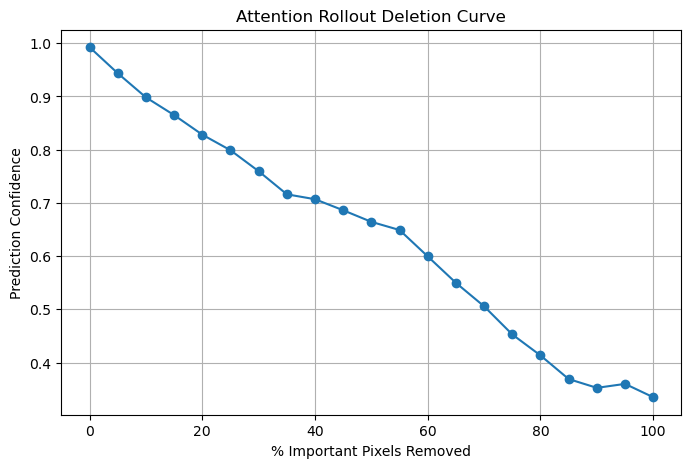

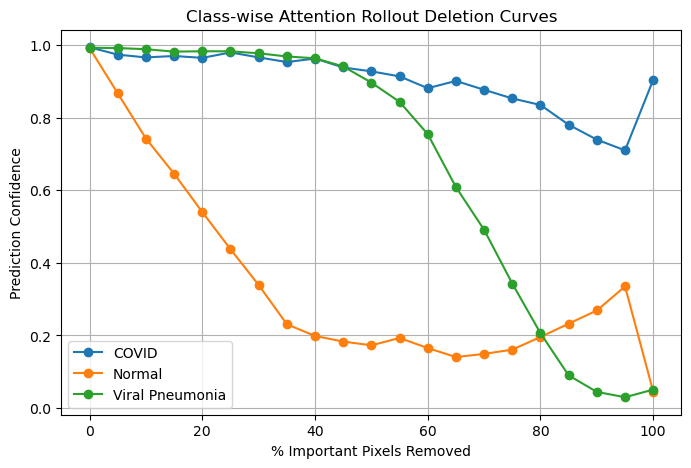

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

steps = 20
N = 400   

sample_indices = random.sample(
    range(len(test_dataset)),
    N
)

mean_curve = np.zeros(
    steps + 1
)

class_curves = {
    0: [],
    1: [],
    2: []
}

for idx in tqdm(sample_indices):

    img, label = test_dataset[idx]

    input_tensor = (
        img.unsqueeze(0)
           .to(device)
    )

    with torch.no_grad():

        output = model(
            input_tensor
        )

        pred_class = (
            output.argmax(1)
                  .item()
        )

  

    rollout_map = get_rollout_map(
        model,
        input_tensor
    )

    rollout_map = (
        rollout_map
        - rollout_map.min()
    ) / (
        rollout_map.max()
        - rollout_map.min()
        + 1e-8
    )

    flat_map = rollout_map.flatten()

    sorted_idx = np.argsort(
        flat_map
    )[::-1]

    confidences = []

   

    for step in range(
        steps + 1
    ):

        frac = (
            step / steps
        )

        modified_img = (
            img.clone()
        )

        n_remove = int(
            frac *
            len(sorted_idx)
        )

        remove_idx = (
            sorted_idx[:n_remove]
        )

        mask = np.ones(
            flat_map.shape,
            dtype=np.float32
        )

        mask[
            remove_idx
        ] = 0

        mask = mask.reshape(
            rollout_map.shape
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        modified_img[:, mask == 0] = -3

        with torch.no_grad():

            prob = torch.softmax(
                model(
                    modified_img
                    .unsqueeze(0)
                    .to(device)
                ),
                dim=1
            )[0, pred_class]

        confidences.append(
            prob.item()
        )

    confidences = np.array(
        confidences
    )

  

    mean_curve += confidences

    class_curves[label].append(
        confidences
    )



mean_curve /= N

for cls in class_curves:

    class_curves[cls] = np.mean(
        class_curves[cls],
        axis=0
    )



x = np.linspace(
    0,
    1,
    steps + 1
)

dauc = np.trapz(
    mean_curve,
    x
)

print(
    f"Overall Rollout DAUC = {dauc:.4f}"
)



for cls in class_curves:

    cls_auc = np.trapz(
        class_curves[cls],
        x
    )

    print(
        f"{test_dataset.classes[cls]} "
        f"DAUC = {cls_auc:.4f}"
    )



plt.figure(
    figsize=(8,5)
)

plt.plot(
    x * 100,
    mean_curve,
    marker='o'
)

plt.xlabel(
    "% Important Pixels Removed"
)

plt.ylabel(
    "Prediction Confidence"
)

plt.title(
    "Attention Rollout Deletion Curve"
)

plt.grid(True)

plt.show()



plt.figure(
    figsize=(8,5)
)

for cls in class_curves:

    plt.plot(
        x * 100,
        class_curves[cls],
        marker='o',
        label=test_dataset.classes[cls]
    )

plt.xlabel(
    "% Important Pixels Removed"
)

plt.ylabel(
    "Prediction Confidence"
)

plt.title(
    "Class-wise Attention Rollout Deletion Curves"
)

plt.legend()

plt.grid(True)

plt.show()

In [51]:
from collections import Counter

labels = [
    test_dataset[idx][1]
    for idx in sample_indices
]

print(Counter(labels))

Counter({0: 134, 1: 134, 2: 132})


100%|██████████| 400/400 [01:32<00:00,  4.31it/s]

Overall Rollout DAUC = 0.5890
COVID DAUC = 0.8198
Normal DAUC = 0.4482
Viral Pneumonia DAUC = 0.4965



C:\Users\sidha\AppData\Local\Temp\ipykernel_23312\3703971035.py:168: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  dauc = np.trapz(
C:\Users\sidha\AppData\Local\Temp\ipykernel_23312\3703971035.py:183: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cls_auc = np.trapz(


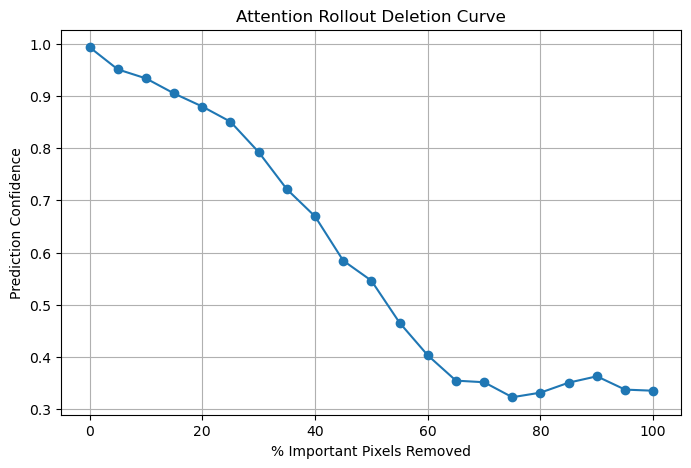

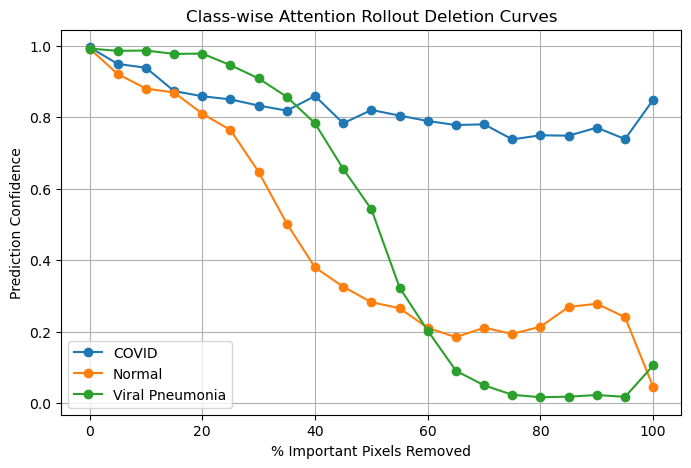

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

steps = 20
N = 400   

sample_indices = random.sample(
    range(len(test_dataset)),
    N
)

mean_curve = np.zeros(
    steps + 1
)

class_curves = {
    0: [],
    1: [],
    2: []
}

for idx in tqdm(sample_indices):

    img, label = test_dataset[idx]

    input_tensor = (
        img.unsqueeze(0)
           .to(device)
    )

    with torch.no_grad():

        output = model(
            input_tensor
        )

        pred_class = (
            output.argmax(1)
                  .item()
        )

  

    rollout_map = get_rollout_map(
        model,
        input_tensor
    )

    rollout_map = (
        rollout_map
        - rollout_map.min()
    ) / (
        rollout_map.max()
        - rollout_map.min()
        + 1e-8
    )

    flat_map = rollout_map.flatten()

    sorted_idx = np.argsort(
        flat_map
    )[::-1]

    confidences = []

   

    for step in range(
        steps + 1
    ):

        frac = (
            step / steps
        )

        modified_img = (
            img.clone()
        )

        n_remove = int(
            frac *
            len(sorted_idx)
        )

        remove_idx = (
            sorted_idx[:n_remove]
        )

        mask = np.ones(
            flat_map.shape,
            dtype=np.float32
        )

        mask[
            remove_idx
        ] = 0

        mask = mask.reshape(
            rollout_map.shape
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        modified_img[:, mask == 0] = -3

        with torch.no_grad():

            prob = torch.softmax(
                model(
                    modified_img
                    .unsqueeze(0)
                    .to(device)
                ),
                dim=1
            )[0, pred_class]

        confidences.append(
            prob.item()
        )

    confidences = np.array(
        confidences
    )

    

    mean_curve += confidences

    class_curves[label].append(
        confidences
    )



mean_curve /= N

for cls in class_curves:

    class_curves[cls] = np.mean(
        class_curves[cls],
        axis=0
    )



x = np.linspace(
    0,
    1,
    steps + 1
)

dauc = np.trapz(
    mean_curve,
    x
)

print(
    f"Overall Rollout DAUC = {dauc:.4f}"
)



for cls in class_curves:

    cls_auc = np.trapz(
        class_curves[cls],
        x
    )

    print(
        f"{test_dataset.classes[cls]} "
        f"DAUC = {cls_auc:.4f}"
    )



plt.figure(
    figsize=(8,5)
)

plt.plot(
    x * 100,
    mean_curve,
    marker='o'
)

plt.xlabel(
    "% Important Pixels Removed"
)

plt.ylabel(
    "Prediction Confidence"
)

plt.title(
    "Attention Rollout Deletion Curve"
)

plt.grid(True)

plt.show()



plt.figure(
    figsize=(8,5)
)

for cls in class_curves:

    plt.plot(
        x * 100,
        class_curves[cls],
        marker='o',
        label=test_dataset.classes[cls]
    )

plt.xlabel(
    "% Important Pixels Removed"
)

plt.ylabel(
    "Prediction Confidence"
)

plt.title(
    "Class-wise Attention Rollout Deletion Curves"
)

plt.legend()

plt.grid(True)

plt.show()

In [69]:
original_conf = mean_curve[0]

aopc = np.mean(
    original_conf - mean_curve[1:]
)

print(
    f"Rollout AOPC = {aopc:.4f}"
)

Rollout AOPC = 0.4204


In [70]:
for cls in class_curves:

    original_conf = class_curves[cls][0]

    cls_aopc = np.mean(
        original_conf
        - class_curves[cls][1:]
    )

    print(
        f"{test_dataset.classes[cls]} "
        f"AOPC = {cls_aopc:.4f}"
    )

COVID AOPC = 0.1793
Normal AOPC = 0.5670
Viral Pneumonia AOPC = 0.5175


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for img, label in test_dataset:

        output = model(
            img.unsqueeze(0).to(device)
        )

        pred = output.argmax(1).item()

        y_true.append(label)
        y_pred.append(pred)



acc = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Accuracy: {acc:.4f}"
)



print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_dataset.classes,
        digits=4
    )
)


cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

Accuracy: 0.9885
                 precision    recall  f1-score   support

          COVID     0.9862    0.9862    0.9862       145
         Normal     0.9863    0.9931    0.9897       145
Viral Pneumonia     0.9931    0.9862    0.9896       145

       accuracy                         0.9885       435
      macro avg     0.9885    0.9885    0.9885       435
   weighted avg     0.9885    0.9885    0.9885       435

[[143   1   1]
 [  1 144   0]
 [  1   1 143]]


In [38]:
model.training

False

In [39]:
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [40]:
model.eval()

map1 = get_rollout_map(
    model,
    input_tensor
)

map2 = get_rollout_map(
    model,
    input_tensor
)

print(
    np.max(
        np.abs(map1 - map2)
    )
)

0.0


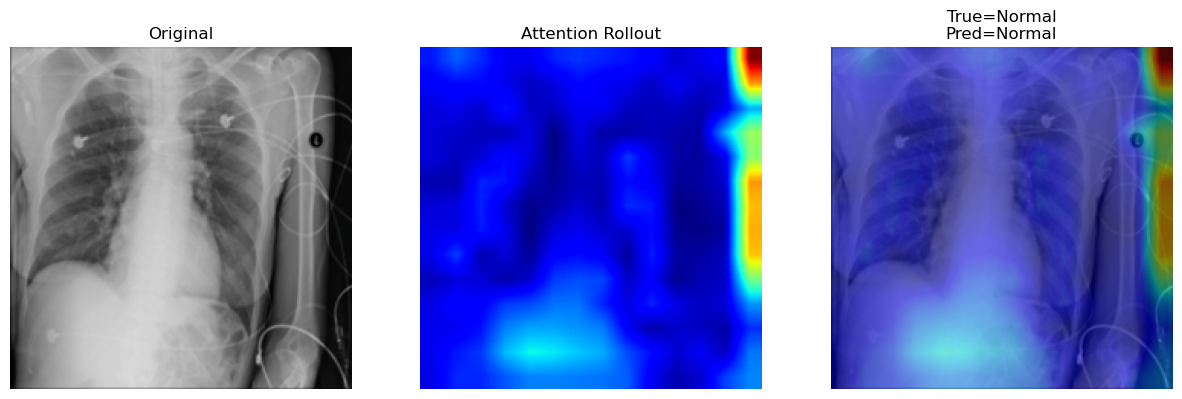

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


idx = 156



img, label = test_dataset[idx]

input_tensor = (
    img.unsqueeze(0)
       .to(device)
)

model.eval()



attentions = []

def hook_fn(module, inp, out):

    if hasattr(module, "attn_map"):

        attentions.append(
            module.attn_map.detach()
        )

handles = []

for block in model.blocks:

    handles.append(
        block.attn.register_forward_hook(
            hook_fn
        )
    )



with torch.no_grad():

    output = model(
        input_tensor
    )

    pred_class = (
        output.argmax(1)
              .item()
    )



for h in handles:

    h.remove()



rollout = torch.eye(
    attentions[0].size(-1),
    device=device
)

for attn in attentions:

    attn_heads_fused = (
        attn.mean(dim=1)[0]
    )

    attn_heads_fused = (
        attn_heads_fused
        + torch.eye(
            attn_heads_fused.size(0),
            device=device
        )
    )

    attn_heads_fused /= (
        attn_heads_fused.sum(
            dim=-1,
            keepdim=True
        )
    )

    rollout = (
        attn_heads_fused
        @ rollout
    )



mask = (
    rollout[0,1:]
    .reshape(14,14)
    .cpu()
    .numpy()
)

mask = (
    mask - mask.min()
) / (
    mask.max()
    - mask.min()
    + 1e-8
)



rgb_img = (
    img.permute(1,2,0)
       .cpu()
       .numpy()
)

rgb_img = rgb_img * std + mean
rgb_img = np.clip(rgb_img,0,1)



from cv2 import resize

mask_vis = resize(
    mask,
    (224,224)
)



fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

ax[0].imshow(rgb_img)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(
    mask_vis,
    cmap="jet"
)

ax[1].set_title(
    "Attention Rollout"
)

ax[1].axis("off")

ax[2].imshow(rgb_img)

ax[2].imshow(
    mask_vis,
    cmap="jet",
    alpha=0.5
)

ax[2].set_title(
    f"True={test_dataset.classes[label]}\n"
    f"Pred={test_dataset.classes[pred_class]}"
)

ax[2].axis("off")

plt.show()